# Walmart Store Sales Forecasting - EDA

ამ notebook-ში ვაანალიზებთ Kaggle-ის `Walmart Recruiting - Store Sales Forecasting` მონაცემებს. მთავარი მიზანია გავიგოთ, როგორია weekly sales-ის დროითი სტრუქტურა, სეზონურობა, holiday ეფექტი, store/dept განსხვავებები და რომელი feature-ები უნდა გამოვიყენოთ forecasting მოდელებში.

ძირითადი დასკვნა: გაყიდვები ძლიერად არის დამოკიდებული საკუთარ წარსულ მნიშვნელობებზე (`lag_1`, `lag_4`, `lag_52`) და Q4 holiday season-ზე. ეკონომიკური ცვლადები (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`) ინდივიდუალურად სუსტ linear signal-ს აჩვენებს, ხოლო store size/type და temporal features ბევრად უფრო ინფორმაციულია.


In [3]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta


from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    KFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

import xgboost as xgb
import lightgbm as lgb

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.impute import SimpleImputer

import holidays

def reduce_memory(df):
    """Downcast numeric types to save RAM"""
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
    return df

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
import kagglehub
import shutil
import os


temp_path = kagglehub.competition_download('walmart-recruiting-store-sales-forecasting')
print("Downloaded temporarily to:", temp_path)

drive_destination = '/content/drive/My Drive/walmart_competition_data'

if not os.path.exists(drive_destination):
    shutil.move(temp_path, drive_destination)
    print("Files successfully moved to your Google Drive at:", drive_destination)
else:
    print("Folder already exists in your Google Drive!")

100%|██████████| 2.70M/2.70M [00:00<00:00, 147MB/s]

Extracting files...
Downloaded temporarily to: /root/.cache/kagglehub/competitions/walmart-recruiting-store-sales-forecasting


Files successfully moved to your Google Drive at: /content/drive/My Drive/walmart_competition_data


In [6]:
import zipfile

with zipfile.ZipFile("/content/drive/My Drive/walmart_competition_data/train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(pwd=b"train.csv")


with zipfile.ZipFile("/content/drive/My Drive/walmart_competition_data/test.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(pwd=b"test.csv")


with zipfile.ZipFile("/content/drive/My Drive/walmart_competition_data/features.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(pwd=b"features.csv")



In [9]:
df_train = pd.read_csv("/content/drive/My Drive/walmart_competition_data/train.csv")
df_test = pd.read_csv("/content/drive/My Drive/walmart_competition_data/test.csv")
df_features = pd.read_csv("/content/drive/My Drive/walmart_competition_data/features.csv")
df_stores = pd.read_csv("/content/drive/My Drive/walmart_competition_data/stores.csv")

In [11]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [12]:
df_test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [13]:
df_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [14]:

df_train_tmp = pd.merge(df_train, df_stores, on='Store', how='left')
df_train_tmp = pd.merge(df_train_tmp, df_features, on=['Store', 'Date', 'IsHoliday'], how='left')

df_train_tmp['Date'] = pd.to_datetime(df_train_tmp['Date'])

df_train = df_train_tmp.copy()


In [15]:
df_train.shape

(421570, 16)

In [16]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [17]:
null = df_train.isna().mean()
print(null)

Store           0.000000
Dept            0.000000
Date            0.000000
Weekly_Sales    0.000000
IsHoliday       0.000000
Type            0.000000
Size            0.000000
Temperature     0.000000
Fuel_Price      0.000000
MarkDown1       0.642572
MarkDown2       0.736110
MarkDown3       0.674808
MarkDown4       0.679847
MarkDown5       0.640790
CPI             0.000000
Unemployment    0.000000
dtype: float64


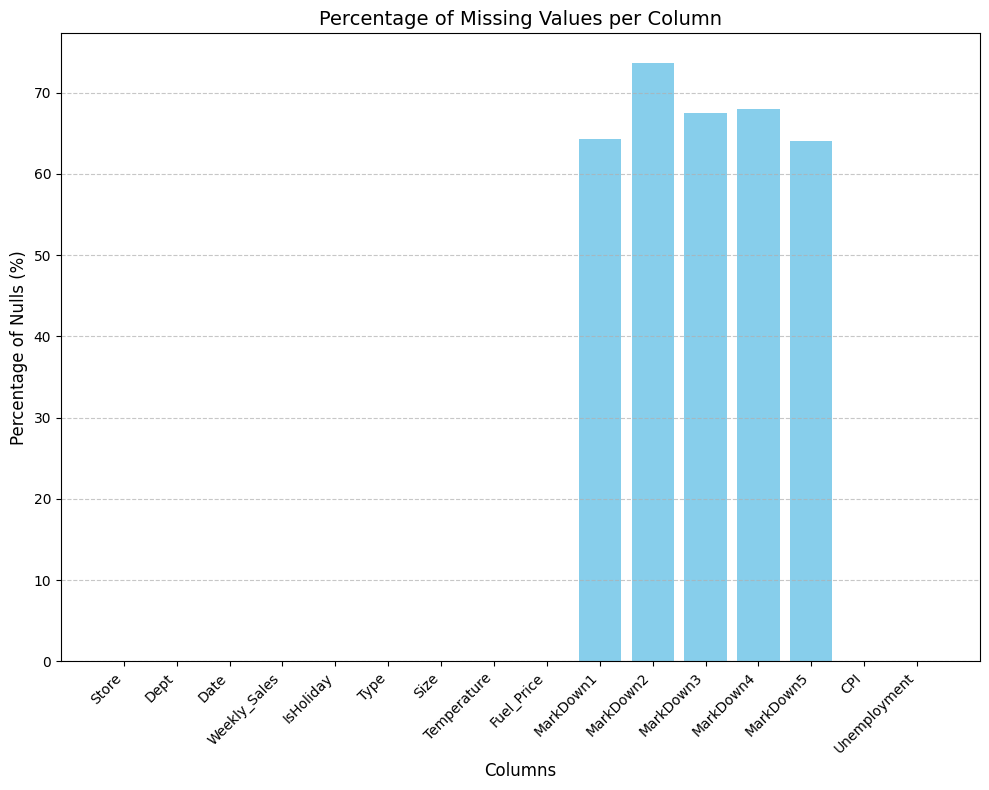

In [18]:
import matplotlib.pyplot as plt

null_percentages = df_train.isnull().mean() * 100

plt.figure(figsize=(10, 8))

plt.bar(null_percentages.index, null_percentages.values, color="skyblue")

plt.title("Percentage of Missing Values per Column", fontsize=14)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Percentage of Nulls (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

In [19]:
import pandas as pd

train_pairs = set(zip(df_train['Store'], df_train['Dept']))
test_pairs = set(zip(df_test['Store'], df_test['Dept']))

missing_in_train = test_pairs - train_pairs
missing_in_test = train_pairs - test_pairs

print(f"Total unique Store-Dept pairs in Train: {len(train_pairs)}")
print(f"Total unique Store-Dept pairs in Test: {len(test_pairs)}")
print(f"Number of Store-Dept pairs in Test but not in Train: {len(missing_in_train)}")
print("\n", len(missing_in_test))
if len(missing_in_train) > 0:
    print("\nAll missing pairs (Store, Dept):")
    display(list(missing_in_train))

print("\n", len(missing_in_train))
if len(missing_in_test) > 0:
    print("\nAll missing pairs (Store, Dept):")
    display(list(missing_in_test))


Total unique Store-Dept pairs in Train: 3331
Total unique Store-Dept pairs in Test: 3169
Number of Store-Dept pairs in Test but not in Train: 11

 173

All missing pairs (Store, Dept):


[(18, 43),
 (24, 43),
 (36, 30),
 (37, 29),
 (25, 99),
 (9, 99),
 (34, 39),
 (45, 39),
 (42, 30),
 (10, 99),
 (5, 99)]


 11

All missing pairs (Store, Dept):


[(33, 36),
 (25, 96),
 (2, 39),
 (30, 55),
 (36, 71),
 (24, 51),
 (11, 51),
 (7, 99),
 (35, 51),
 (27, 77),
 (3, 77),
 (39, 51),
 (22, 99),
 (11, 78),
 (26, 78),
 (40, 77),
 (16, 77),
 (15, 78),
 (34, 58),
 (42, 41),
 (41, 51),
 (17, 51),
 (28, 51),
 (19, 48),
 (1, 51),
 (17, 78),
 (28, 78),
 (29, 43),
 (21, 48),
 (12, 45),
 (32, 78),
 (42, 34),
 (27, 45),
 (6, 77),
 (30, 41),
 (25, 45),
 (34, 78),
 (45, 78),
 (5, 78),
 (45, 96),
 (29, 45),
 (21, 96),
 (33, 6),
 (20, 51),
 (18, 51),
 (21, 50),
 (7, 51),
 (36, 41),
 (33, 24),
 (41, 37),
 (30, 34),
 (33, 33),
 (7, 78),
 (18, 78),
 (9, 51),
 (11, 48),
 (22, 78),
 (12, 77),
 (23, 77),
 (3, 83),
 (15, 48),
 (13, 51),
 (9, 78),
 (36, 34),
 (43, 27),
 (13, 78),
 (35, 78),
 (25, 77),
 (33, 35),
 (44, 99),
 (19, 45),
 (39, 78),
 (29, 77),
 (10, 51),
 (11, 50),
 (32, 48),
 (26, 50),
 (21, 45),
 (41, 78),
 (36, 36),
 (1, 78),
 (15, 77),
 (26, 77),
 (27, 51),
 (3, 51),
 (3, 78),
 (14, 78),
 (4, 77),
 (15, 43),
 (18, 39),
 (29, 51),
 (16, 51),
 (40

Frequency of actual time gaps found:
diff_days
7.0      412792
14.0       2346
21.0        862
28.0        517
35.0        338
          ...  
658.0         1
672.0         1
707.0         1
791.0         1
882.0         1
Name: count, Length: 80, dtype: int64


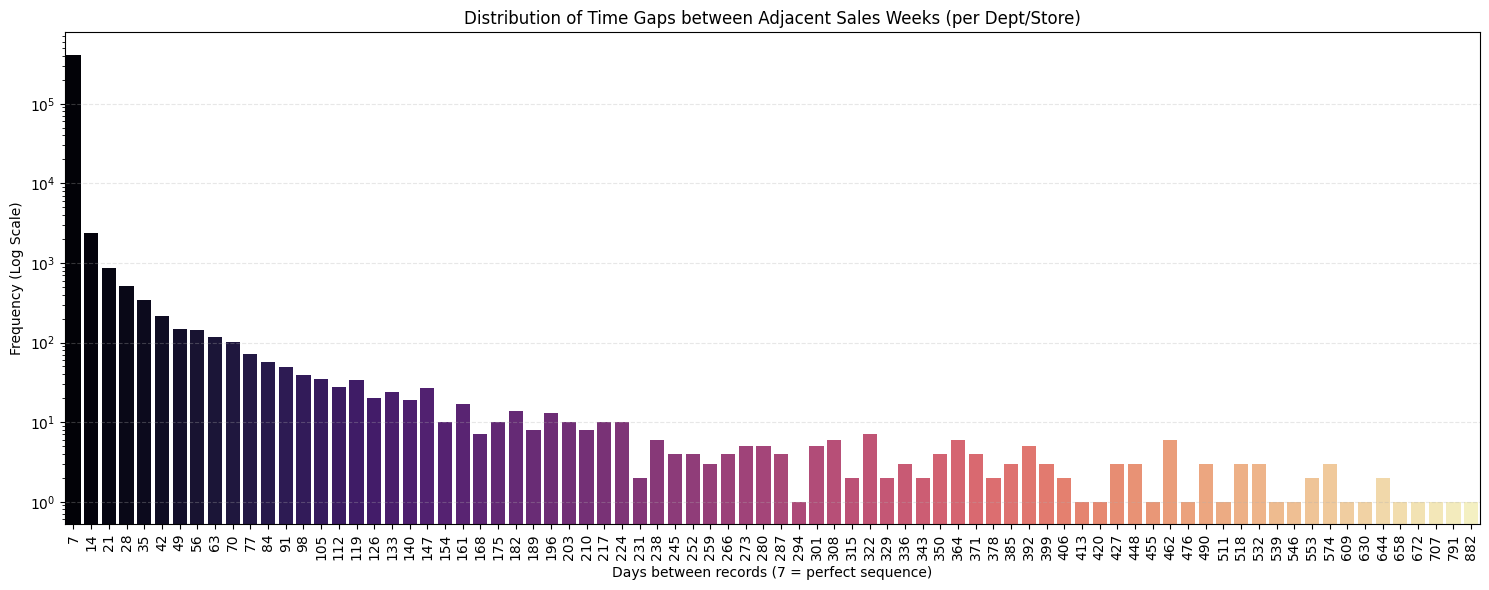

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df_train['Date'] = pd.to_datetime(df_train['Date'])
df_train = df_train.sort_values(['Store', 'Dept', 'Date'])

df_train['diff_days'] = df_train.groupby(['Store', 'Dept'])['Date'].diff().dt.days

diff_counts = df_train['diff_days'].value_counts().sort_index()

plot_data = diff_counts[diff_counts > 0]

print("Frequency of actual time gaps found:")
print(plot_data)

plt.figure(figsize=(15, 6))
sns.barplot(x=plot_data.index.astype(int), y=plot_data.values, palette='magma')

plt.yscale('log')
plt.title('Distribution of Time Gaps between Adjacent Sales Weeks (per Dept/Store)')
plt.xlabel('Days between records (7 = perfect sequence)')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### დაკვირვება: დროითი რიგის უწყვეტობა

Train set-ში გვაქვს 421,570 ჩანაწერი, 45 store, 81 department და 143 weekly თარიღი (`2010-02-05` - `2012-10-26`). Store/Dept წყვილების უმეტესობა ყოველ 7 დღეში ერთხელ მეორდება, რაც forecasting ამოცანას რეგულარულ weekly time-series ფორმატთან აახლოებს. თუმცა plot-ზე ჩანს იშვიათი უფრო დიდი gap-ებიც, ამიტომ lag/rolling feature-ების შექმნისას grouping უნდა გაკეთდეს `Store` + `Dept` დონეზე და missing history უნდა დამუშავდეს ცალკე.

Test-ში არის 3,169 Store/Dept წყვილი, train-ში კი 3,331. Test-ში 11 წყვილი საერთოდ არ ჩანს train-ში, რაც cold-start პრობლემას ქმნის. ასეთი შემთხვევებისთვის მოდელს უნდა ჰქონდეს fallback feature-ები store/type/size/dept/year/week დონეზე და არ უნდა დაეყრდნოს მხოლოდ historical lags-ს.


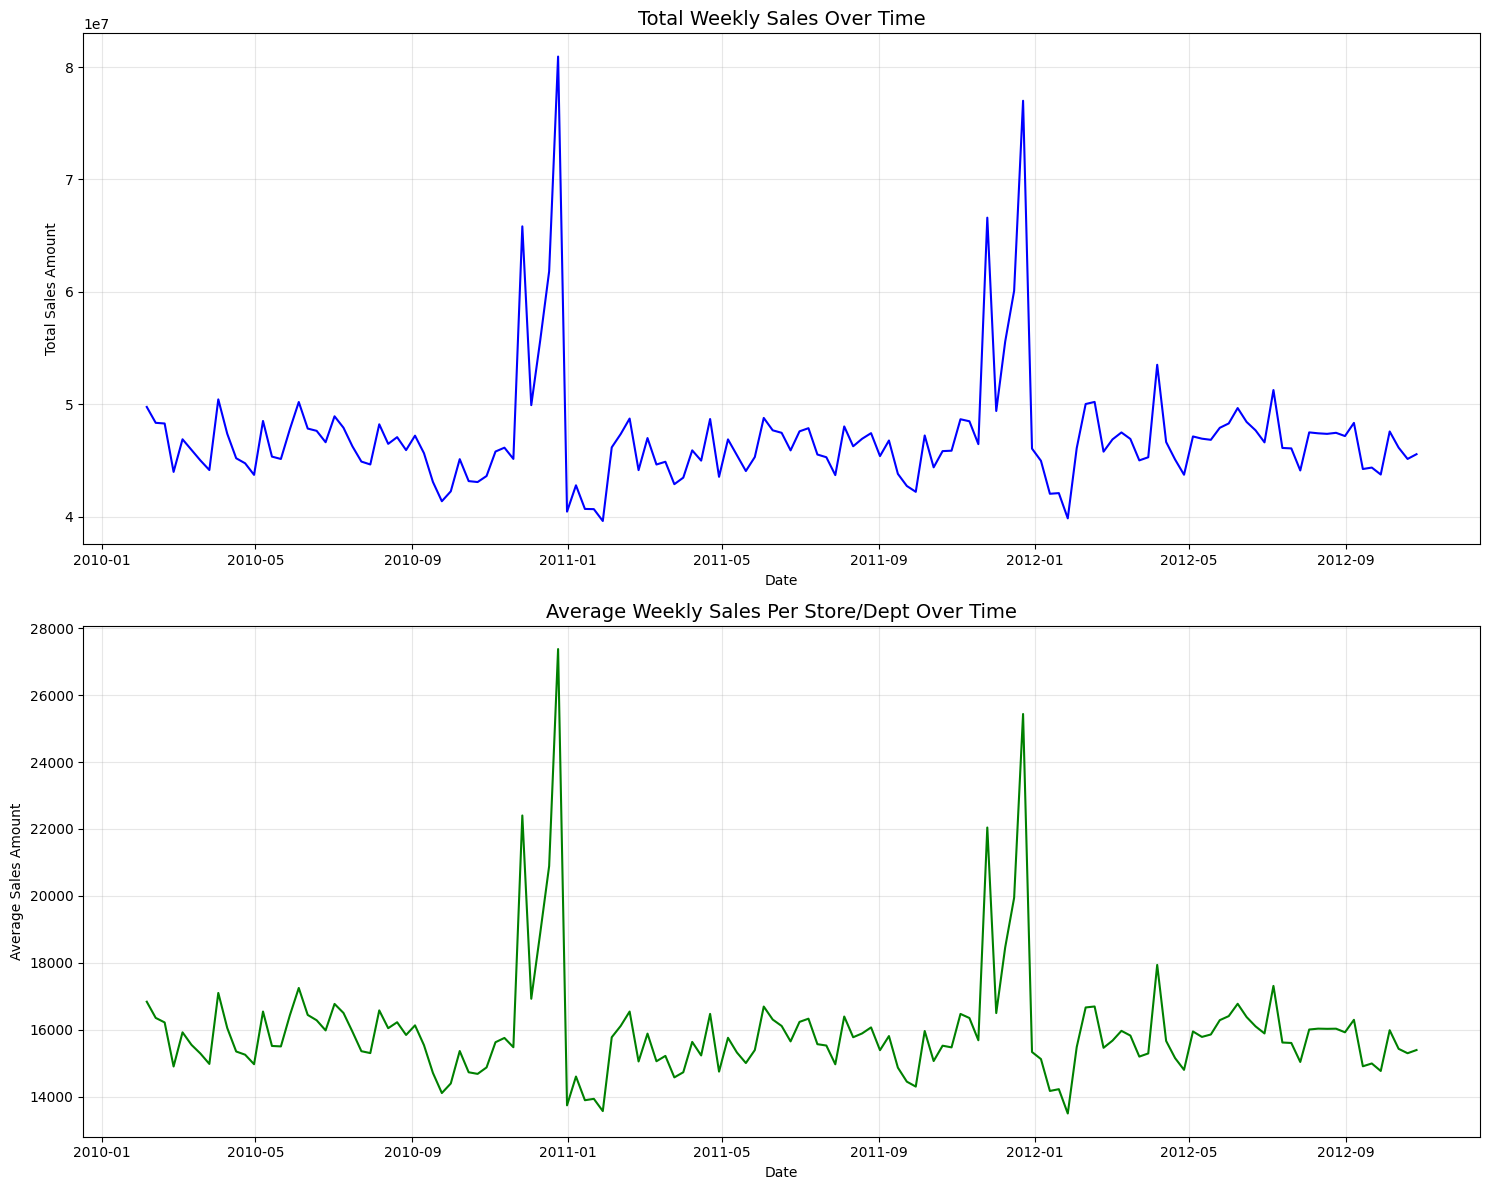

In [21]:
time_series_df = df_train.groupby('Date')['Weekly_Sales'].agg(['sum', 'mean']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.lineplot(data=time_series_df, x='Date', y='sum', ax=axes[0], color='blue')
axes[0].set_title('Total Weekly Sales Over Time', fontsize=14)
axes[0].set_ylabel('Total Sales Amount')
axes[0].grid(True, alpha=0.3)

sns.lineplot(data=time_series_df, x='Date', y='mean', ax=axes[1], color='green')
axes[1].set_title('Average Weekly Sales Per Store/Dept Over Time', fontsize=14)
axes[1].set_ylabel('Average Sales Amount')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### დაკვირვება: საერთო ტრენდი და holiday spikes

Weekly sales-ის time-series სტაბილურ საბაზისო დონეს ინარჩუნებს, მაგრამ წლის ბოლოს ძალიან მკვეთრი peaks აქვს. ყველაზე დიდი ზრდები ემთხვევა Thanksgiving/Christmas სეზონს: 2010 და 2011 წლის ნოემბერ-დეკემბერში total და average sales ერთდროულად იზრდება. ეს ნიშნავს, რომ მოდელში აუცილებლად უნდა შევიდეს calendar/holiday feature-ები და, იდეალურად, სპეციალური holiday proximity feature-ები.

2012 წლის total sales bar შედარებით დაბალია არა იმიტომ, რომ წელი აუცილებლად სუსტია, არამედ იმიტომ, რომ train მონაცემები 2012-ში მხოლოდ `2012-10-26`-მდე გვაქვს. Year-level aggregation-ის ინტერპრეტაციისას ეს censoring უნდა გავითვალისწინოთ.


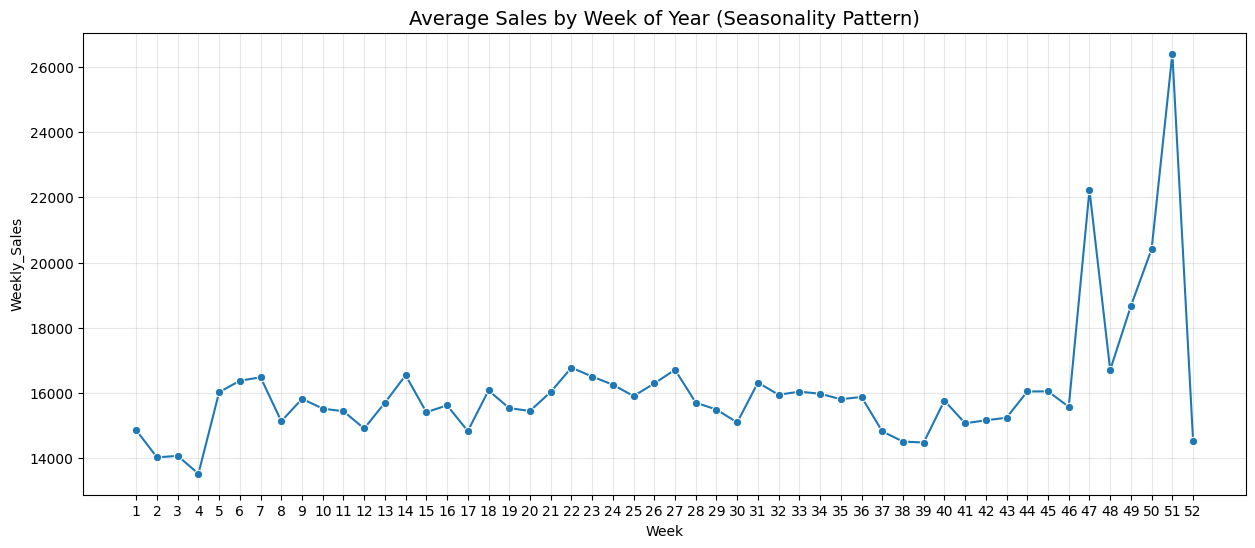

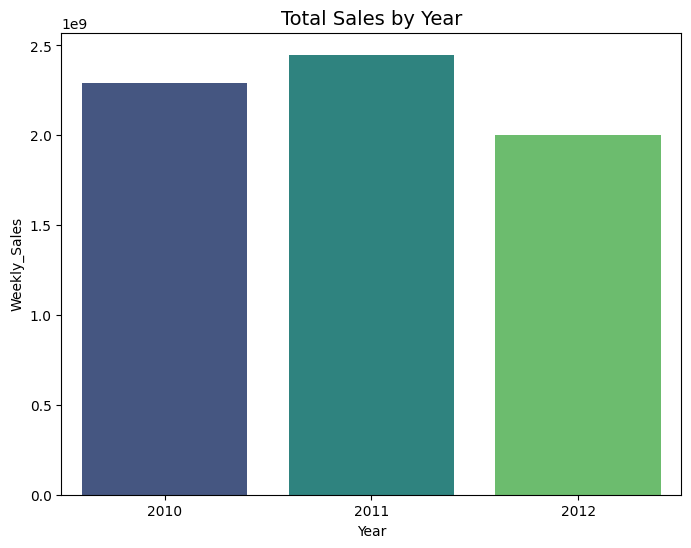

In [41]:
df_train['Week'] = df_train['Date'].dt.isocalendar().week
df_train['Year'] = df_train['Date'].dt.year

weekly_agg = df_train.groupby('Week')['Weekly_Sales'].mean().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=weekly_agg, x='Week', y='Weekly_Sales', marker='o')
plt.title('Average Sales by Week of Year (Seasonality Pattern)', fontsize=14)
plt.xticks(range(1, 53))
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=df_train, x='Year', y='Weekly_Sales', estimator=sum, errorbar=None, palette='viridis')
plt.title('Total Sales by Year', fontsize=14)
plt.show()


In [ ]:
holiday_comparison = df_train.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=holiday_comparison, x='IsHoliday', y='Weekly_Sales', palette='Set2')
plt.title('Average Weekly Sales: Holiday vs. Non-Holiday', fontsize=14)
plt.ylabel('Average Sales Amount')
plt.show()

In [ ]:
# Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
# Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
# Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
# Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

def get_holiday_name(row):
    if not row['IsHoliday']:
        return 'Non-Holiday'
    date_str = row['Date'].strftime('%Y-%m-%d')
    if date_str in ['2010-02-12', '2011-02-11', '2012-02-10']:
        return 'Super Bowl'
    elif date_str in ['2010-09-10', '2011-09-09', '2012-09-07']:
        return 'Labor Day'
    elif date_str in ['2010-11-26', '2011-11-25', '2012-11-23']:
        return 'Thanksgiving'
    elif date_str in ['2010-12-31', '2011-12-30', '2012-12-28']:
        return 'Christmas'
    else:
        return 'Other Holiday'

df_train['Holiday_Name'] = df_train.apply(get_holiday_name, axis=1)

# Calculate average sales by holiday type
holiday_type_sales = df_train[df_train['Holiday_Name'] != 'Non-Holiday'].groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=holiday_type_sales, x='Holiday_Name', y='Weekly_Sales', palette='viridis')
plt.title('Average Sales by Holiday Type', fontsize=14)
plt.ylabel('Average Sales Amount')
plt.show()

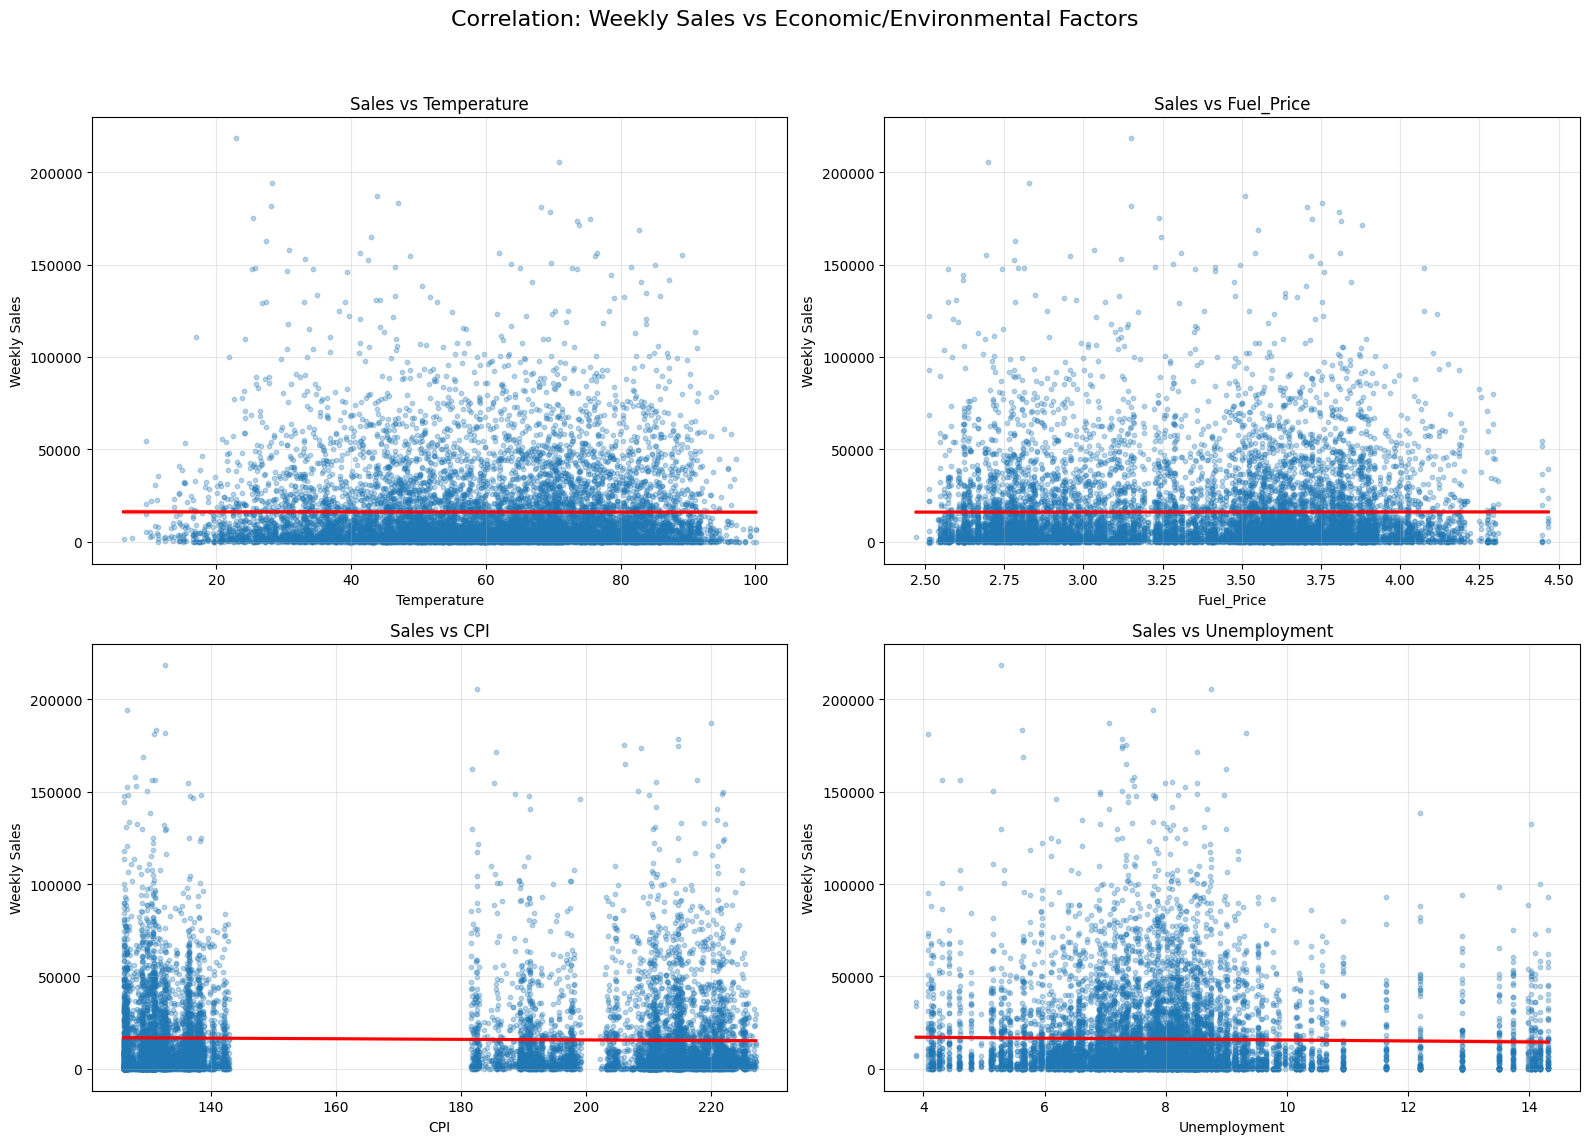

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Correlation: Weekly Sales vs Economic/Environmental Factors', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(features):
    if 'df_train' in globals():
        sns.regplot(data=df_train.sample(n=10000, random_state=42), x=col, y='Weekly_Sales',
                    ax=axes[i], scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
        axes[i].set_title(f'Sales vs {col}')
        axes[i].set_ylabel('Weekly Sales')
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, 'df_train not defined', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

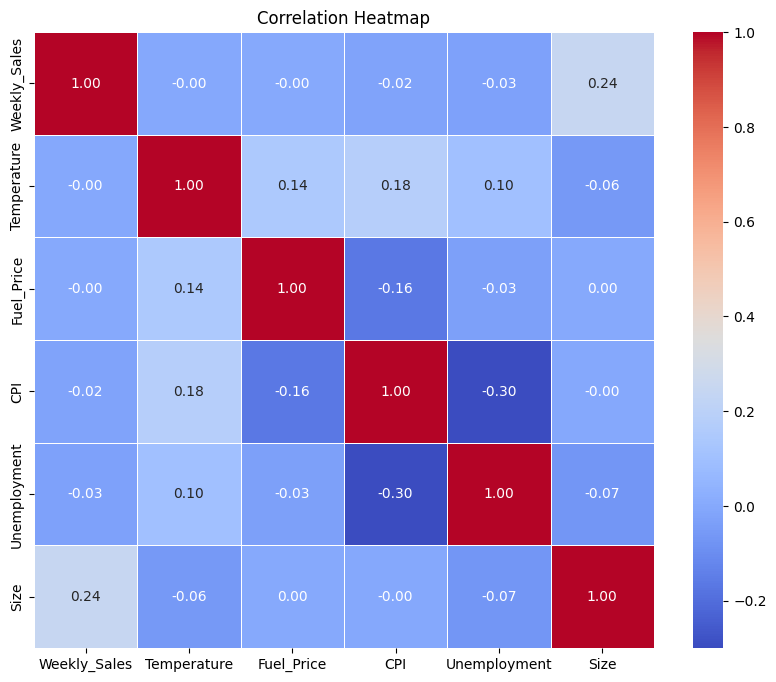

In [26]:
if 'df_train' in globals():
    corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']
    correlation_matrix = df_train[corr_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print('Error: df_train is not defined. Please run the data loading cells first.')

### დაკვირვება: გარე ფაქტორების signal

`Temperature`, `Fuel_Price`, `CPI` და `Unemployment` Weekly_Sales-თან თითქმის ნულოვან linear correlation-ს აჩვენებს. ეს არ ნიშნავს, რომ ისინი სრულიად უსარგებლოა: ეფექტი შეიძლება იყოს nonlinear, store-specific ან seasonal interaction-ის სახით. მაგალითად, temperature-ის გავლენა სავარაუდოდ department-ზეა დამოკიდებული.

ყველაზე მკაფიო non-temporal signal არის `Size` (`corr ~= 0.24`): დიდი stores უფრო მაღალ weekly sales-ს აწარმოებენ. ამიტომ `Type`, `Size`, `Store`, `Dept` და მათი interaction-ები განსაკუთრებით მნიშვნელოვანია tree-based მოდელებისთვის.


### Feature Engineering: Lags and Rolling Windows
We create these features per `Store` and `Dept` to capture local trends. We use `.shift(1)` for rolling windows to ensure we only use *past* information, preventing data leakage.

In [34]:
import numpy as np

df_train = df_train.sort_values(['Store', 'Dept', 'Date'])

df_train['lag_1'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
df_train['lag_4'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)
df_train['lag_13'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(13)
df_train['lag_52'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)

df_train['rolling_mean_4'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda s: s.shift(1).rolling(window=4).mean())
df_train['rolling_mean_13'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda s: s.shift(1).rolling(window=13).mean())
df_train['rolling_std_4'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda s: s.shift(1).rolling(window=4).std())
df_train['rolling_std_13'] = df_train.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(lambda s: s.shift(1).rolling(window=13).std())

display(df_train[['Store', 'Dept', 'Date', 'Weekly_Sales', 'lag_1', 'lag_52', 'rolling_mean_4']].tail())


,Store,Dept,Date,Weekly_Sales,lag_1,lag_52,rolling_mean_4
421565,45,98,2012-09-28,508.37,467.30,727.05,442.9350
421566,45,98,2012-10-05,628.10,508.37,894.98,483.5175
421567,45,98,2012-10-12,1061.02,628.10,996.40,552.4325
421568,45,98,2012-10-19,760.01,1061.02,1058.84,666.1975
421569,45,98,2012-10-26,1076.80,760.01,1167.90,739.3750


### Visualizing Autocorrelation
These scatter plots show how strongly current sales relate to past sales. A tight diagonal line indicates a strong predictor.

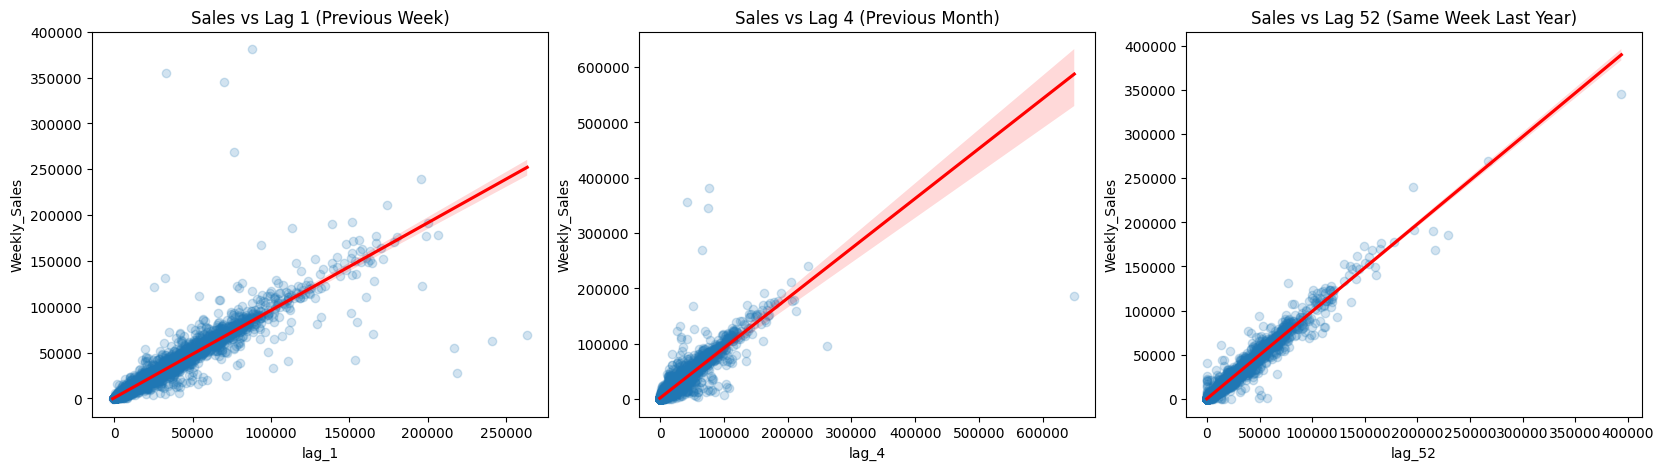

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.regplot(data=df_train.sample(10000, random_state=1), x='lag_1', y='Weekly_Sales', ax=axes[0], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[0].set_title('Sales vs Lag 1 (Previous Week)')

sns.regplot(data=df_train.sample(10000, random_state=1), x='lag_4', y='Weekly_Sales', ax=axes[1], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[1].set_title('Sales vs Lag 4 (Previous Month)')

sns.regplot(data=df_train.sample(10000, random_state=1), x='lag_52', y='Weekly_Sales', ax=axes[2], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[2].set_title('Sales vs Lag 52 (Same Week Last Year)')

plt.show()

### Temporal Feature Correlation
This heatmap reveals which engineered features have the strongest linear relationship with `Weekly_Sales`.

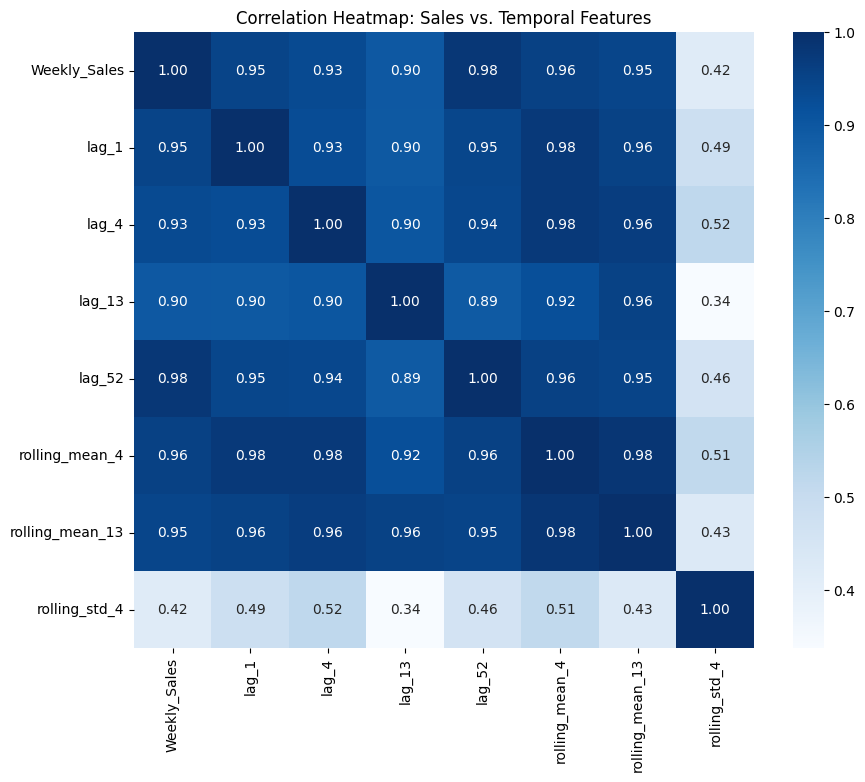

In [35]:
features_to_check = ['Weekly_Sales', 'lag_1', 'lag_4', 'lag_13', 'lag_52',
                     'rolling_mean_4', 'rolling_mean_13', 'rolling_std_4']

plt.figure(figsize=(10, 8))
sns.heatmap(df_train[features_to_check].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap: Sales vs. Temporal Features')
plt.show()

### დაკვირვება: temporal feature-ები ყველაზე ძლიერი predictors არიან

Lag და rolling feature-ები Weekly_Sales-თან ძალიან მაღალ კავშირს აჩვენებს: `lag_1`, `lag_4`, `lag_52`, `rolling_mean_4` და `rolling_mean_13` მიმდინარე გაყიდვებთან ახლოს მიყვება. ეს ამოცანის მთავარი signal-ია და ხსნის, რატომ უნდა ვცადოთ როგორც classical time-series მოდელები, ისე tabular boosting მოდელები lag/rolling feature-ებით.

მნიშვნელოვანია leakage control: rolling feature-ები უნდა დაითვალოს `.shift(1)`-ის შემდეგ, ანუ მხოლოდ წარსული კვირებიდან. Forecast horizon-ზე test set-ისთვის lag-ების გენერაცია recursive ან expanding update ლოგიკას საჭიროებს.


### Case Study: Store 1, Dept 1
We plot the actual sales against our engineered rolling means to see how they track the general trend and seasonality.

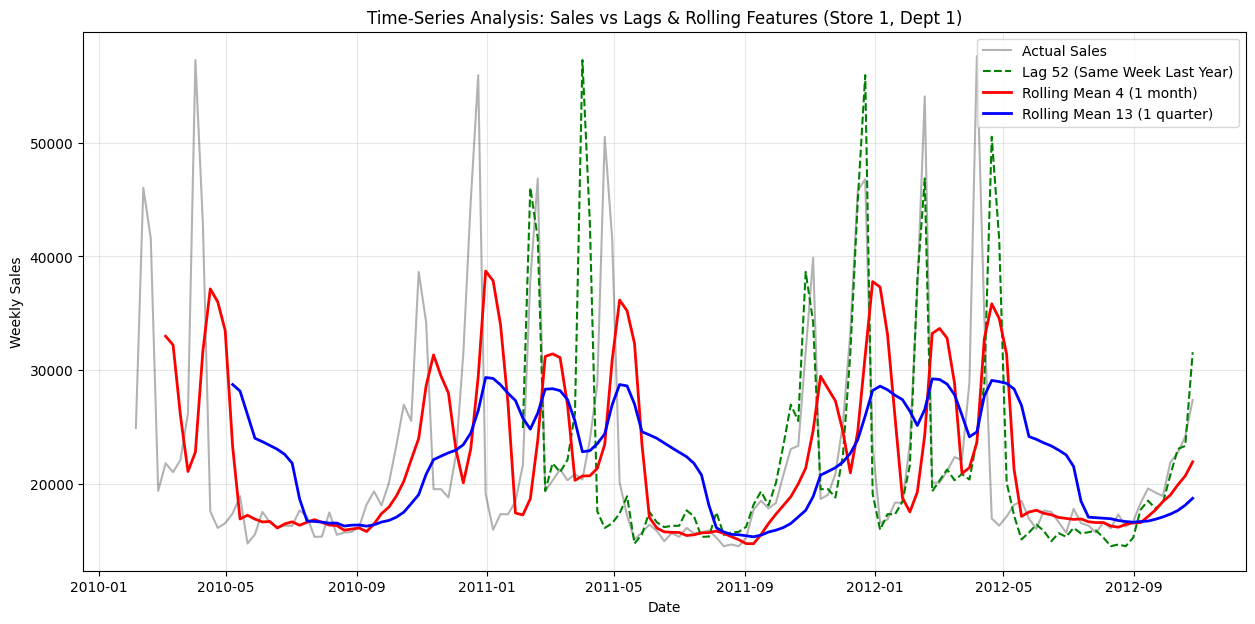

In [36]:
sample_ts = df_train[(df_train['Store'] == 1) & (df_train['Dept'] == 1)]

plt.figure(figsize=(15, 7))
plt.plot(sample_ts['Date'], sample_ts['Weekly_Sales'], label='Actual Sales', color='black', alpha=0.3)
plt.plot(sample_ts['Date'], sample_ts['lag_52'], label='Lag 52 (Same Week Last Year)', linestyle='--', color='green')
plt.plot(sample_ts['Date'], sample_ts['rolling_mean_4'], label='Rolling Mean 4 (1 month)', color='red', linewidth=2)
plt.plot(sample_ts['Date'], sample_ts['rolling_mean_13'], label='Rolling Mean 13 (1 quarter)', color='blue', linewidth=2)

plt.title('Time-Series Analysis: Sales vs Lags & Rolling Features (Store 1, Dept 1)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Analysis of High-Sales Departments
Rolling means allow us to see the underlying trend by filtering out weekly noise. For high-volume departments, these smoothed lines are essential for identifying shifts in consumer behavior.

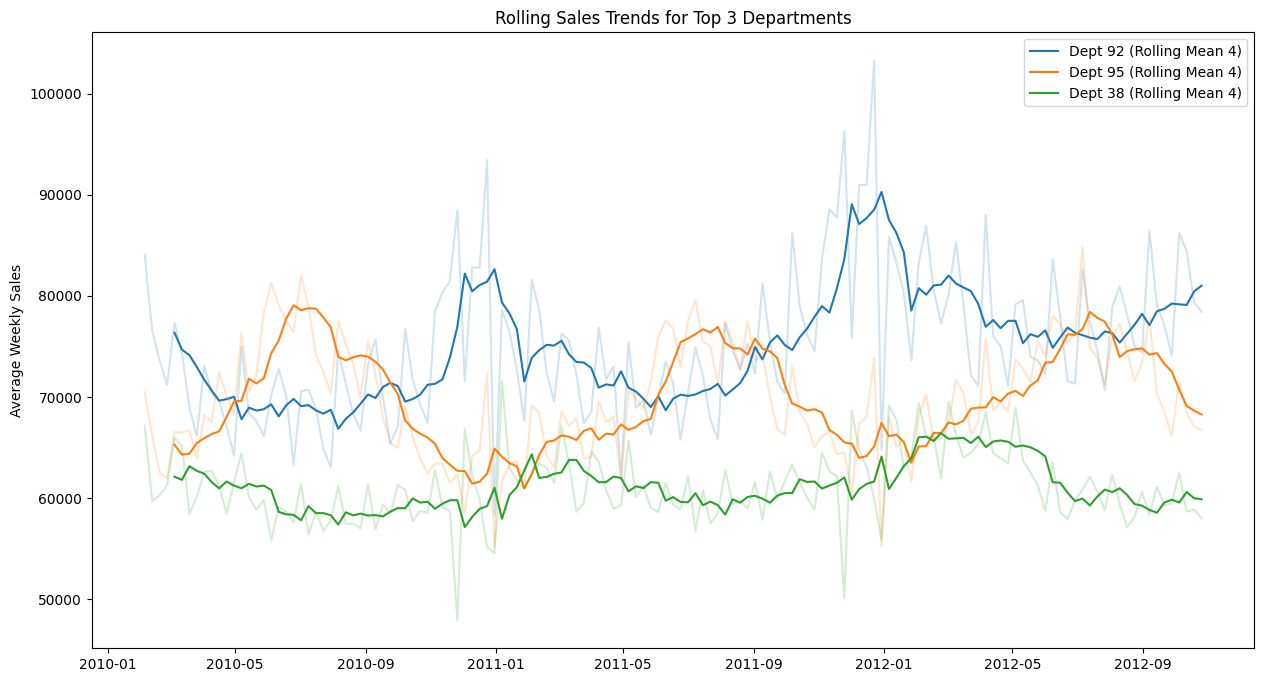

In [33]:
top_depts = df_train.groupby('Dept')['Weekly_Sales'].sum().nlargest(3).index.tolist()

plt.figure(figsize=(15, 8))
for dept in top_depts:
    dept_data = df_train[df_train['Dept'] == dept].groupby('Date')['Weekly_Sales'].mean().reset_index()
    dept_data['rolling_4'] = dept_data['Weekly_Sales'].shift(1).rolling(4).mean()

    line = plt.plot(dept_data['Date'], dept_data['Weekly_Sales'], alpha=0.2)
    plt.plot(dept_data['Date'], dept_data['rolling_4'], label=f'Dept {dept} (Rolling Mean 4)', color=line[0].get_color())

plt.title('Rolling Sales Trends for Top 3 Departments')
plt.legend()
plt.ylabel('Average Weekly Sales')
plt.show()

### Deep Dive: MarkDown Analysis
The MarkDown columns represent promotional data. Since they have many missing values (mostly before Nov 2011), let's see how they correlate with sales when they *are* present.

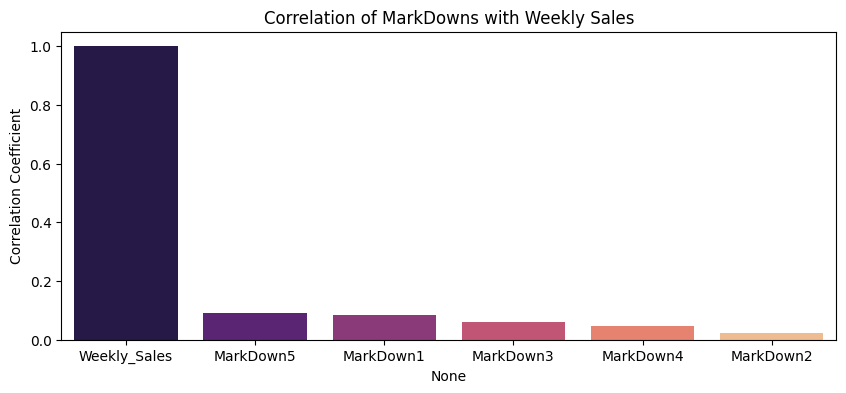

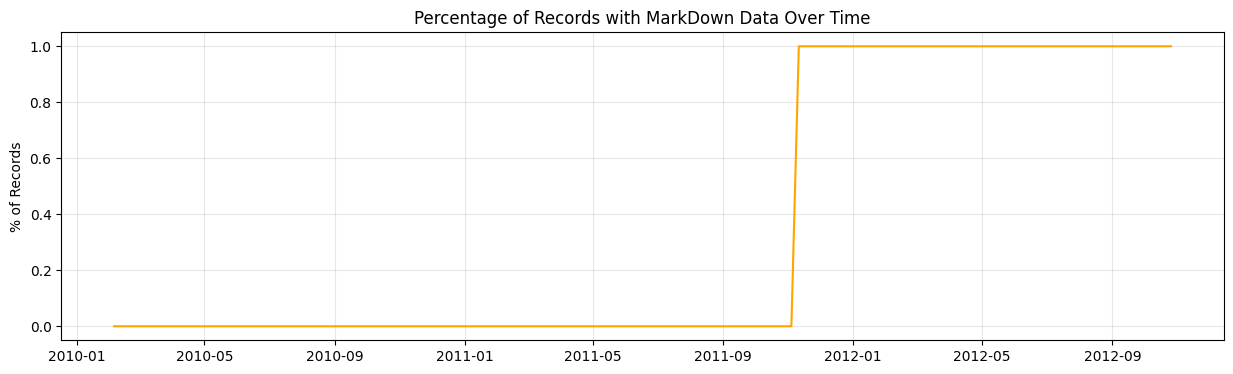

In [37]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

md_corr = df_train[markdown_cols + ['Weekly_Sales']].corr()['Weekly_Sales'].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=md_corr.index, y=md_corr.values, palette='magma')
plt.title('Correlation of MarkDowns with Weekly Sales')
plt.ylabel('Correlation Coefficient')
plt.show()

df_train['Has_MarkDown'] = df_train[markdown_cols].notnull().any(axis=1)
md_presence = df_train.groupby('Date')['Has_MarkDown'].mean().reset_index()

plt.figure(figsize=(15, 4))
plt.plot(md_presence['Date'], md_presence['Has_MarkDown'], color='orange')
plt.title('Percentage of Records with MarkDown Data Over Time')
plt.ylabel('% of Records')
plt.grid(True, alpha=0.3)
plt.show()

### დაკვირვება: Markdown ცვლადები

Markdown data თითქმის მთლიანად ჩნდება `2011-11-11`-დან. მანამდე ეს სვეტები missing არის, ამიტომ მათ პირდაპირ ნულით შევსებას შეიძლება ორაზროვანი მნიშვნელობა ჰქონდეს: ნული შეიძლება ნიშნავდეს no promotion-ს ან unavailable data-ს. უკეთესი მიდგომაა Markdown amount-ების შევსება domain-aware წესით და დამატებითი binary indicators (`has_markdown_i`) შექმნა.

Weekly sales-თან Markdown correlations სუსტია, მაგრამ positive. Promotion effect სავარაუდოდ holiday weeks-ზე, department-ზე და markdown type-ზეა დამოკიდებული, ამიტომ მათი interaction-ები tree-based მოდელებში უფრო გამოსადეგი იქნება, ვიდრე მარტივი linear correlation.


### Store Type & Size Impact
Walmart classifies stores into types A, B, and C. Let's see how size and type interact to influence sales.

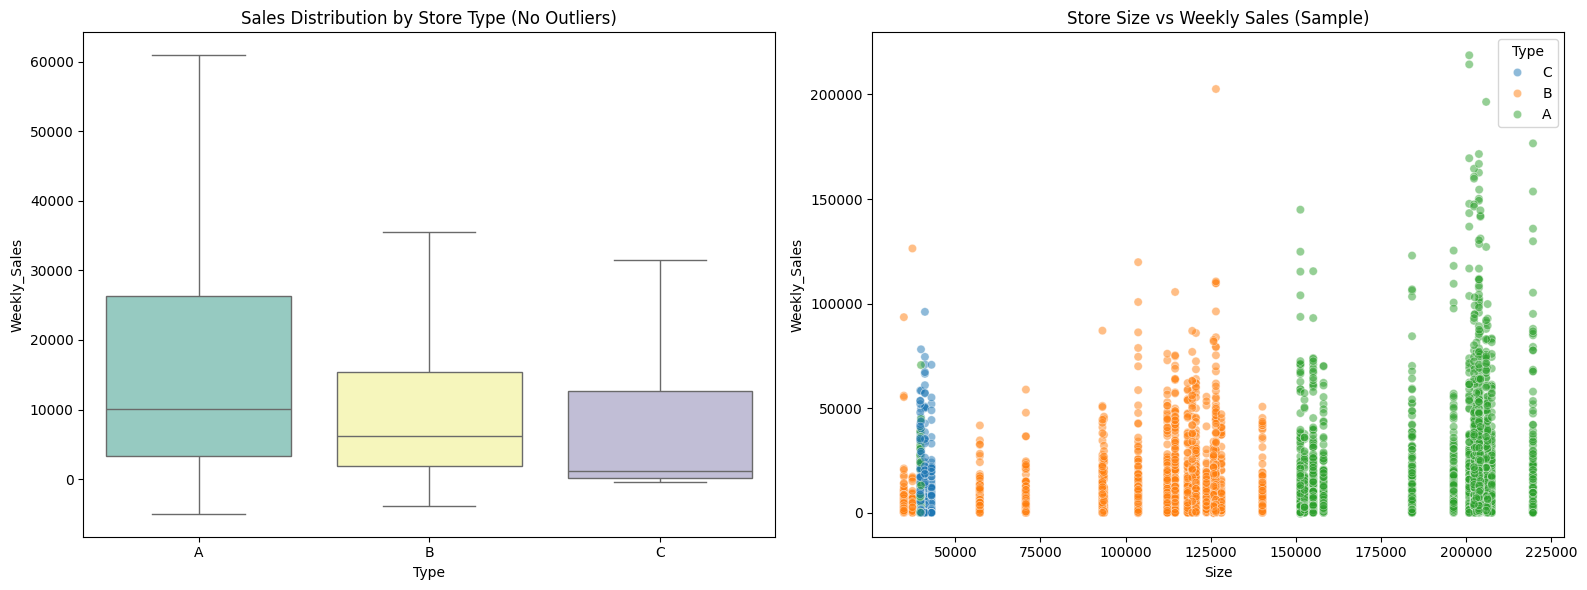

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales Distribution by Store Type
sns.boxplot(data=df_train, x='Type', y='Weekly_Sales', ax=axes[0], palette='Set3', showfliers=False)
axes[0].set_title('Sales Distribution by Store Type (No Outliers)')

# Store Size vs Sales colored by Type
sns.scatterplot(data=df_train.sample(5000), x='Size', y='Weekly_Sales', hue='Type', alpha=0.5, ax=axes[1])
axes[1].set_title('Store Size vs Weekly Sales (Sample)')

plt.tight_layout()
plt.show()

### დაკვირვება: store type და size

Type A stores ყველაზე დიდი და მაღალი გაყიდვების მქონე სეგმენტია; Type C პატარაა და დაბალი median sales აქვს. Size-ის scatterplot აჩვენებს, რომ store capacity sales level-ს ზრდის, მაგრამ spread ძალიან დიდია. ეს გვკარნახობს, რომ `Store`/`Dept` fixed effects ან categorical encodings საჭიროა, რადგან მხოლოდ `Size` ვერ ხსნის department-level variation-ს.


### Month-over-Month Growth
Finally, we can look at the average growth rates per month to identify if there are specific months that consistently outperform the others across all years.

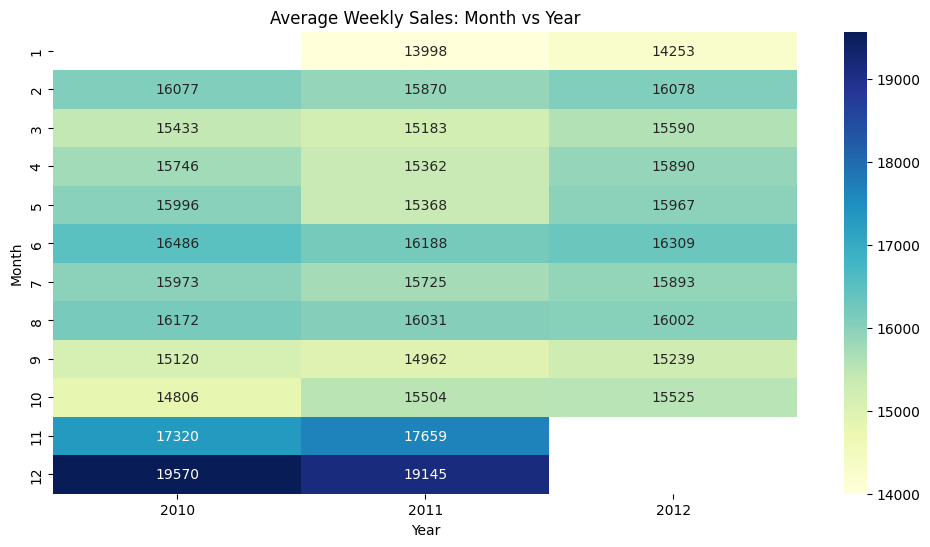

In [40]:
df_train['Month'] = df_train['Date'].dt.month
df_train['Year'] = df_train['Date'].dt.year
monthly_sales = df_train.groupby(['Year', 'Month'])['Weekly_Sales'].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_sales, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Weekly Sales: Month vs Year')
plt.show()

### საბოლოო EDA დასკვნები

1. Forecasting-ის მთავარი signal არის historical sales: `lag_1`, `lag_4`, `lag_13`, `lag_52` და shifted rolling averages.
2. Seasonality ძლიერია, განსაკუთრებით November-December და week 47-51 პერიოდში. Week-of-year, month, holiday flag და holiday name/proximity feature-ები აუცილებელია.
3. External economic variables მარტო სუსტ linear signal-ს იძლევა, მაგრამ interaction-ებში შეიძლება დაეხმაროს მოდელს.
4. Markdown data late-start feature-ია და missingness თვითონაც ინფორმაციულია.
5. Store type/size და department-level განსხვავებები დიდია, ამიტომ global model-ს უნდა ჰქონდეს categorical identifiers და aggregate fallback features cold-start Store/Dept წყვილებისთვის.
